In [ ]:
# Imports
import os
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets, models
from tqdm import tqdm

print('Imports done')

Imports done


## Import the dataset

In [ ]:
# Update this path if your processed dataset is located elsewhere on Kaggle
processed_dataset_path = '/kaggle/input/liver-us-processed'

print('Listing processed dataset path:')
print(os.listdir(processed_dataset_path))

classes = os.listdir(processed_dataset_path)
print('Folder classes (filesystem):', classes)

Listing processed dataset path:
['F0', 'F1', 'F4', 'F3', 'F2']
Folder classes (filesystem): ['F0', 'F1', 'F4', 'F3', 'F2']


## Train AlexNet (pretrained on ImageNet)

Test mode only uses a small number of images per class for quick smoke-testing. Set `test_mode = False` for full training.

In [ ]:
test_mode = False

# Hyperparameters / reproducibility
use_gpu = True
random_seed = 42

# Hyperparameters (match ResNet notebook)
batch_size = 8 if not test_mode else 8
num_epochs = 50 if not test_mode else 5
learning_rate = 1e-4
num_workers = 4
device = torch.device('cuda' if (use_gpu and torch.cuda.is_available()) else 'cpu')
print('Using device:', device)
torch.manual_seed(random_seed)
random.seed(random_seed)
np.random.seed(random_seed)

Using device: cuda


### Train-Test Split and DataLoaders

This follows the same approach as the ResNet notebook: create an `ImageFolder` with `ToTensor()` only, build per-class indices, and either do a small `test_mode` subset or an 80/20 random split.

In [ ]:
# Minimal transform to load raw tensors (consistent with the ResNet notebook)
to_tensor_only = transforms.Compose([
    transforms.ToTensor(),
])

# Create ImageFolder datasets with no additional transforms
full_train_dataset = datasets.ImageFolder(processed_dataset_path, transform=to_tensor_only)
full_val_dataset = datasets.ImageFolder(processed_dataset_path, transform=to_tensor_only)

classes = full_train_dataset.classes
num_classes = len(classes)
print('Found classes:', classes, 'num_classes =', num_classes)

# Build indices per class
indices_by_class = {i: [] for i in range(num_classes)}
for idx, (_, label) in enumerate(full_train_dataset.samples):
    indices_by_class[label].append(idx)

# For reproducibility shuffle each class list
for k in indices_by_class:
    random.shuffle(indices_by_class[k])

if test_mode:
    # select up to 5 samples per class for training, the rest become validation
    train_indices = []
    val_indices = []
    for k, idxs in indices_by_class.items():
        n_train_per_class = min(5, len(idxs))
        train_chunk = idxs[:n_train_per_class]
        val_chunk = idxs[n_train_per_class:]
        train_indices.extend(train_chunk)
        val_indices.extend(val_chunk)
else:
    # standard 80/20 split across the whole dataset
    n_total = len(full_train_dataset)
    n_train = int(0.8 * n_total)
    all_indices = list(range(n_total))
    random.shuffle(all_indices)
    train_indices = all_indices[:n_train]
    val_indices = all_indices[n_train:]

# Create Subset datasets
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)
print(f'Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

Found classes: ['F0', 'F1', 'F2', 'F3', 'F4'] num_classes = 5
Train samples: 5058, Val samples: 1265


### Model Config

In [ ]:
# Build AlexNet (pretrained)
# Using the new torchvision weights API for parity with ResNet notebook
model = models.alexnet(weights='DEFAULT')

# Replace final classifier layer to match number of classes
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# Scheduler (same pattern as ResNet)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(model)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 197MB/s] 


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for inputs, targets in pbar:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        pbar.set_postfix(loss=running_loss/total, acc=100. * correct/total)
    epoch_loss = running_loss / total if total>0 else 0
    epoch_acc = correct / total if total>0 else 0
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        pbar = tqdm(loader, desc='Eval', leave=False)
        for inputs, targets in pbar:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            all_targets.extend(targets.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
    epoch_loss = running_loss / total if total>0 else 0
    epoch_acc = correct / total if total>0 else 0
    return epoch_loss, epoch_acc, all_targets, all_preds, all_probs

### Training Loop

In [ ]:
# Training loop (matches ResNet notebook behavior)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_wts = None

patience = 7  # stop if no improvement for this many epochs
epochs_without_improvement = 0
start_time = time.time()
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = {k: v.cpu() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:
        print(f'Early stopping: no improvement for {patience} epochs')
        break

total_time = time.time() - start_time
print(f'Training complete in {total_time//60:.0f}m {total_time%60:.0f}s. Best val acc: {best_val_acc:.4f}')

Epoch 1/50


Train loss: 0.8584 acc: 0.6125 | Val loss: 0.7169 acc: 0.6656
Epoch 2/50


Train loss: 0.5837 acc: 0.7459 | Val loss: 0.4587 acc: 0.8103
Epoch 3/50


Train loss: 0.4204 acc: 0.8246 | Val loss: 0.3070 acc: 0.8688
Epoch 4/50


Train loss: 0.3088 acc: 0.8818 | Val loss: 0.2589 acc: 0.9028
Epoch 5/50


...

Train loss: 0.0041 acc: 0.9990 | Val loss: 0.0504 acc: 0.9897
Epoch 17/50


Train loss: 0.0034 acc: 0.9994 | Val loss: 0.0510 acc: 0.9897
Epoch 18/50


Train loss: 0.0035 acc: 0.9992 | Val loss: 0.0512 acc: 0.9897
Epoch 19/50


Train loss: 0.0019 acc: 1.0000 | Val loss: 0.0522 acc: 0.9897
Epoch 20/50


Train loss: 0.0034 acc: 0.9994 | Val loss: 0.0518 acc: 0.9897
Early stopping: no improvement for 7 epochs
Training complete in 14m 18s. Best val acc: 0.9905


### Loading the best model and Evaluation

In [ ]:
# Load best weights back into model
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)

# Final evaluation on validation set and collect predictions
val_loss, val_acc, val_targets, val_preds, val_probs = evaluate(model, val_loader, criterion, device)
print(f'Final val loss: {val_loss:.4f}, val acc: {val_acc:.4f}')

Final val loss: 0.0504, val acc: 0.9905


### Plotting Training Curves and Metrics

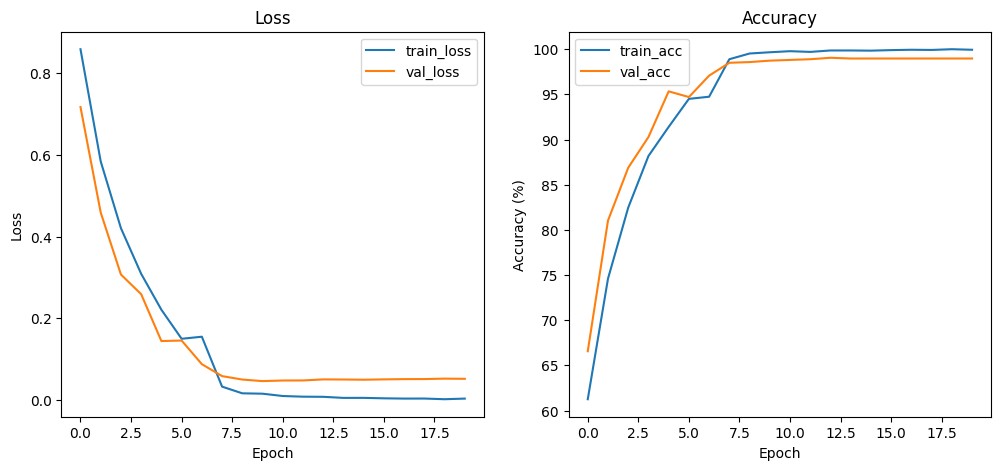

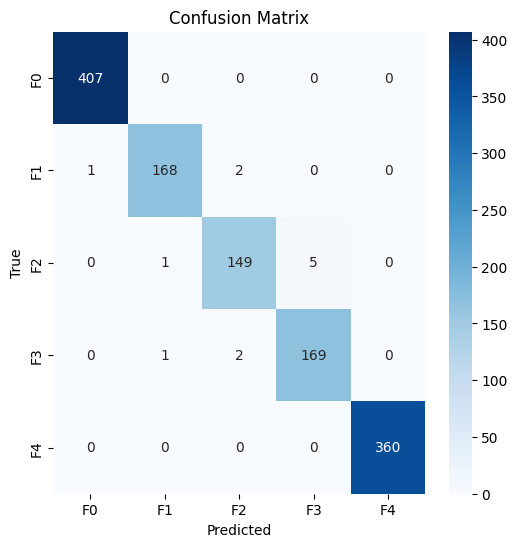


Classification report:
              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       407
          F1       0.99      0.98      0.99       171
          F2       0.97      0.96      0.97       155
          F3       0.97      0.98      0.98       172
          F4       1.00      1.00      1.00       360

    accuracy                           0.99      1265
   macro avg       0.99      0.99      0.99      1265
weighted avg       0.99      0.99      0.99      1265



In [ ]:
# Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot([x*100 for x in history['train_acc']], label='train_acc')
plt.plot([x*100 for x in history['val_acc']], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy')
plt.show()

# Confusion matrix (small datasets may have classes missing in val)
try:
    from sklearn.metrics import confusion_matrix, classification_report
    cm = confusion_matrix(val_targets, val_preds, labels=list(range(num_classes)))
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    print('\nClassification report:')
    print(classification_report(val_targets, val_preds, target_names=classes, zero_division=0))
except Exception as e:
    print('Could not compute confusion matrix or classification report:', e)

### Exporting the Model

In [ ]:
# Export model
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

# Save state_dict
torch.save(model.state_dict(), out_dir / 'alexnet_state_dict.pth')

# Save full model (may be large)
torch.save(model, out_dir / 'alexnet_full_model.pt')

print(f'Saved model to {out_dir}')
print(f'  - State dict: {out_dir / "alexnet_state_dict.pth"}')
print(f'  - Full model: {out_dir / "alexnet_full_model.pt"}')

Saved model to outputs
  - State dict: outputs/alexnet_state_dict.pth
  - Full model: outputs/alexnet_full_model.pt
